<a href="https://colab.research.google.com/github/sajjaporn-sr/My-coursework/blob/main/SS_Sonar_Mine_classification_using_Psuedoinverse_and_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Description**: A step-by-step implementation of the classification using Psuedoinverse and Gradient descent methods, developed from scratch using Python.

**Tools Used**: Python, Pandas, Numpy.

**Key Learning**: Understanding the mathematical foundations of classification using Psuedoinverse and Gradient descent by solving the equations.

**Import dataset**

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d mayurdalvi/sonar-mine-dataset

Dataset URL: https://www.kaggle.com/datasets/mayurdalvi/sonar-mine-dataset
License(s): CC0-1.0
  0% 0.00/29.1k [00:00<?, ?B/s]
100% 29.1k/29.1k [00:00<00:00, 21.3MB/s]


In [ ]:
!unzip sonar-mine-dataset.zip

Archive:  sonar-mine-dataset.zip
  inflating: sonar data.csv          


In [ ]:
import pandas as pd

In [ ]:
column = []
for i in range(60):
  column.append(i+1)
column.append('class')

In [ ]:
data = pd.read_csv('sonar data.csv', names=column)
data

,1,2,3,4,5,6,7,8,9,10,...,52,53,54,55,56,57,58,59,60,class
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


**Convert 'class' to '0 & 1' (R (Rock) = 0 & M (Mine) = 1)**

In [ ]:
data['class'] = data['class'].apply(lambda x: 1 if x=='M' else 0)

# **Compute X using Psuedoinverse**

**From AX = B, we have**

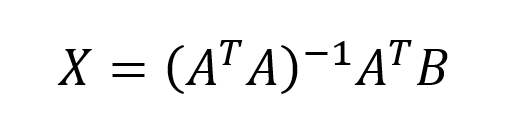

**Construct feature matrix (A) and class labels (B) from the dataframe**

In [ ]:
import numpy as np

A = np.array(data.drop('class', axis=1))
B = np.array(data['class'])

In [ ]:
X = np.linalg.inv(A.T @ A) @ (A.T @ B)

In [ ]:
print(X)

[ 2.06492466e+00  2.13594899e+00 -6.16749291e+00  3.42829236e+00
 -1.44168089e-02  8.18447665e-01 -1.28528360e+00 -7.24163615e-01
  8.09292383e-01 -3.87942665e-01  3.31634225e-01  8.80963006e-01
  5.84426603e-01 -3.81338576e-01  3.29205930e-01 -3.72537138e-01
 -6.43130851e-01  8.91969725e-01 -6.01342830e-01  5.23441060e-01
 -5.82944211e-01  5.33209364e-01 -4.64855358e-01  1.17541622e+00
 -7.62818645e-01 -7.47495387e-03  3.91427986e-01 -1.61538988e-01
 -6.68310701e-01  1.69210317e+00 -1.99029030e+00  8.68295469e-01
 -3.26155427e-02 -7.14479793e-01  1.17148406e+00 -1.10272343e+00
 -1.07190957e-01  8.41925854e-02  6.43142913e-01 -7.38721791e-01
  3.35422564e-01 -3.18593038e-01  8.98921223e-02  2.06941753e-01
  2.39965001e-01 -1.59225857e-01  1.22047860e+00  3.96618871e-01
  4.90645981e+00 -9.98774243e+00 -2.33752735e+00  3.39156302e+00
  5.03480795e+00  6.54873436e+00 -1.21393937e+01 -3.94577218e+00
 -1.70762545e+00  8.35421592e+00  6.61762413e+00 -3.56455487e+00]


Predict B from A and X

In [ ]:
B_predict = A @ X

for i in range((B_predict).shape[0]):
  if (B_predict)[i] > 0.5:
    (B_predict)[i] = 1
  else:
    (B_predict)[i] = 0

print(B_predict)

[0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
error = B - B_predict
square_error = error ** 2

print(square_error.sum()/len(B))

0.09615384615384616


# **Compute X using Gradient Descent**

Define XW = Y, where X shape is 208x60, W shape is 60x1, Y shape is 208x1

In [ ]:
X = A
Y = B
W_0 = np.random.rand(X.shape[1])

In [ ]:
print(X.shape)
print(W_0.shape)
print(Y.shape)
print(W_0)

(208, 60)
(60,)
(208,)
[0.56673678 0.13175328 0.45640124 0.2698743  0.96359144 0.46509391
 0.41307295 0.15979123 0.14733097 0.92933153 0.2020094  0.50118776
 0.31033497 0.84781637 0.07333505 0.08117404 0.89736609 0.851287
 0.70965234 0.46301653 0.18233405 0.2231817  0.37399026 0.79697725
 0.15522418 0.29551669 0.41389935 0.22809119 0.29809585 0.3555398
 0.59297635 0.45146606 0.7110545  0.08170321 0.17941905 0.38424902
 0.16748756 0.36850169 0.678508   0.89205151 0.68241884 0.415798
 0.73826215 0.93910233 0.49952011 0.97596813 0.02794814 0.48357175
 0.09316688 0.32255633 0.93972058 0.36266854 0.17519896 0.46180044
 0.08241648 0.42283805 0.35695598 0.83951712 0.91647147 0.78088491]


Define Loss:

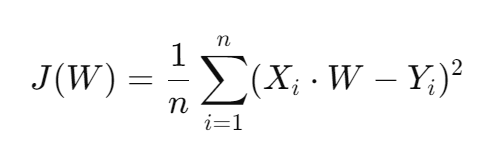

We have Gradient:

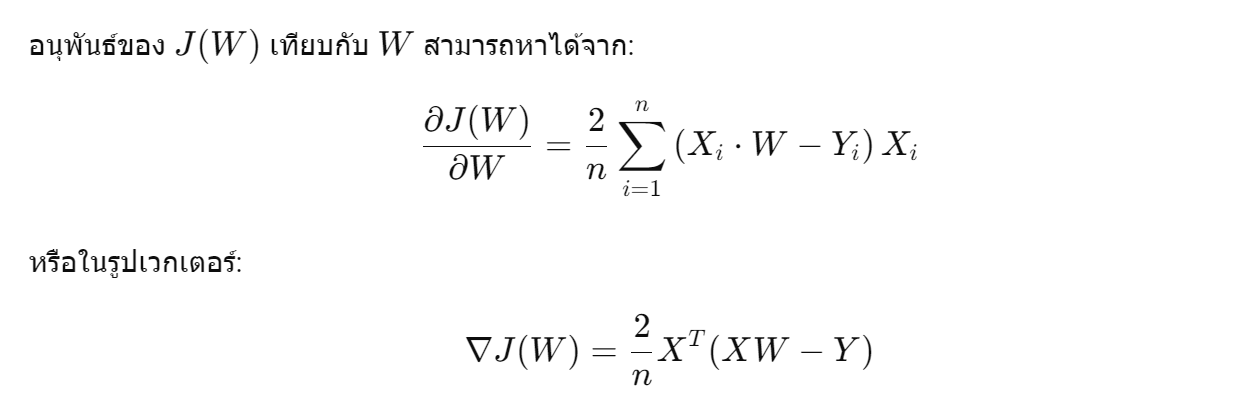

In [ ]:
def grad(W):
  return (2/len(X))* X.T @ (X @ W - Y)

Use Gradient Descent to update the weight matrix (W)

In [ ]:
ln = 0.1
W = W_0

for i in range(500):
  W = W - ln*grad(W)
  Y_pred = X @ W
  for i in range((Y_pred).shape[0]):
    if (Y_pred)[i] > 0.5:
      (Y_pred)[i] = 1
    else:
      (Y_pred)[i] = 0
  error = Y - Y_pred
  square_error = error ** 2
  print(square_error.sum()/len(Y))


0.5336538461538461
0.46634615384615385
0.5240384615384616
0.3894230769230769
0.4375
0.3605769230769231
0.3701923076923077
0.3557692307692308
0.3605769230769231
0.3605769230769231
0.35096153846153844
0.34615384615384615
0.33653846153846156
0.3269230769230769
0.3269230769230769
0.3125
0.2932692307692308
0.28846153846153844
0.28365384615384615
0.27884615384615385
0.2692307692307692
0.2644230769230769
0.25961538461538464
0.2644230769230769
0.25961538461538464
0.25
0.25
0.25
0.25
0.2403846153846154
0.23557692307692307
0.23557692307692307
0.23557692307692307
0.23557692307692307
0.23557692307692307
0.23076923076923078
0.23076923076923078
0.23076923076923078
0.22596153846153846
0.22115384615384615
0.21634615384615385
0.21153846153846154
0.20673076923076922
0.20673076923076922
0.20192307692307693
0.20192307692307693
0.20673076923076922
0.20673076923076922
0.20673076923076922
0.21153846153846154
0.21153846153846154
0.21153846153846154
0.21153846153846154
0.21634615384615385
0.21634615384615385
0

Predict Y from X and W

In [ ]:
Y_pred = X @ W

for i in range((Y_pred).shape[0]):
  if (Y_pred)[i] > 0.5:
    (Y_pred)[i] = 1
  else:
    (Y_pred)[i] = 0

print(Y_pred)

[1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
error = Y - Y_pred
square_error = error ** 2

print(square_error.sum()/len(B))

0.17307692307692307
